# Part 2: Motor imagery decoding with CSP + LDA

Classifying imagined hand vs feet movement from EEG, using the PhysioNet EEGBCI dataset (64 channels, 160 Hz).
Runs 6, 10 and 14 are the imagery runs where T1 is both fists and T2 is both feet.

Imagining a movement suppresses the 8 to 30 Hz mu and beta rhythms over motor cortex. CSP learns spatial filters that maximise the variance difference between the two classes, and LDA classifies the log-variance of those filtered signals.
Chance is 50%.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from mne.decoding import CSP
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import ShuffleSplit, LeaveOneGroupOut, cross_val_score

mne.set_log_level("WARNING")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

## One subject

In [2]:
def load_raw(subject):
    files = eegbci.load_data(subject, [6, 10, 14])
    raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in files])
    eegbci.standardize(raw)  # fix channel names
    raw.set_montage("colin27_1005")
    raw.filter(7.0, 30.0, skip_by_annotation="edge")  # mu + beta
    return raw

raw = load_raw(1)
events, _ = mne.events_from_annotations(raw, event_id=dict(T1=2, T2=3))
epochs = mne.Epochs(raw, events, dict(hands=2, feet=3), tmin=-1.0, tmax=4.0,
                    picks="eeg", baseline=None, preload=True)
print(epochs)

<Epochs | 45 events (all good), -1 – 4 s (baseline off), ~17.7 MiB, data loaded,
 'hands': 21
 'feet': 24>


In [3]:
X = epochs.copy().crop(tmin=1.0, tmax=2.0).get_data(copy=False)  # 1 to 2 s after cue
y = epochs.events[:, -1] - 2  # 0 = hands, 1 = feet
print(X.shape, np.bincount(y))

(45, 64, 161) [21 24]


In [4]:
clf = Pipeline([("csp", CSP(n_components=4, log=True)),
                ("lda", LinearDiscriminantAnalysis())])
cv = ShuffleSplit(10, test_size=0.2, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv)
print(f"Accuracy: {scores.mean():.2f} +/- {scores.std():.2f} (chance 0.50)")

Accuracy: 0.93 +/- 0.07 (chance 0.50)


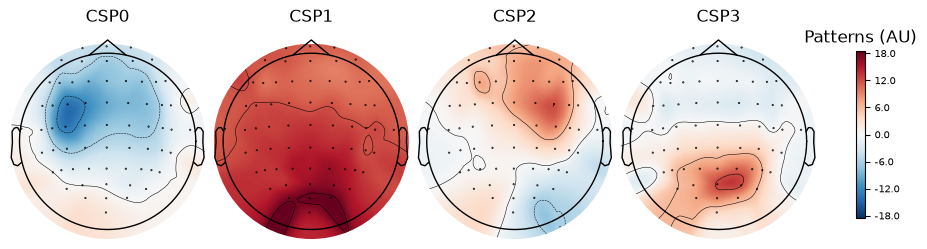

In [5]:
clf.fit(X, y)
fig = clf.named_steps["csp"].plot_patterns(epochs.info, components=range(4), ch_type="eeg", units="Patterns (AU)", size=1.5, show=False)
fig.savefig(FIG / "csp_patterns_s1.png", dpi=120, bbox_inches="tight")

The patterns should sit over the central electrodes (C3, Cz, C4), roughly motor cortex. Patterns over the eyes or at the edges would mean the model is picking up artifacts instead.

## Other classifiers

Swapping LDA for logistic regression, and also skipping CSP entirely and using band power per channel (mu 8 to 13 Hz and beta 13 to 30 Hz) with logistic regression and gradient boosting.

In [6]:
def band_power(X, sfreq=epochs.info["sfreq"]):
    psd, freqs = mne.time_frequency.psd_array_welch(X, sfreq, fmin=7, fmax=30, n_fft=int(sfreq), verbose=False)
    mu = psd[..., (freqs >= 8) & (freqs < 13)].mean(-1)
    beta = psd[..., (freqs >= 13) & (freqs <= 30)].mean(-1)
    return np.log(np.concatenate([mu, beta], axis=1))

bp = FunctionTransformer(band_power)

models = {
    "CSP + LDA": clf,
    "CSP + logreg": make_pipeline(CSP(n_components=4, log=True), LogisticRegression(max_iter=1000)),
    "band power + logreg": make_pipeline(bp, StandardScaler(), LogisticRegression(C=0.1, max_iter=1000)),
    "band power + grad boosting": make_pipeline(bp, HistGradientBoostingClassifier(random_state=0)),
}
rows = {}
for name, model in models.items():
    s = cross_val_score(model, X, y, cv=cv)
    rows[name] = dict(mean=s.mean().round(3), std=s.std().round(3))
pd.DataFrame(rows).T

,mean,std
CSP + LDA,0.933,0.074
CSP + logreg,0.922,0.071
band power + logreg,0.622,0.151
band power + grad boosting,0.356,0.130


## Time windows

In [7]:
windows = [(0.0, 1.0), (0.5, 1.5), (1.0, 2.0), (0.5, 2.5), (1.0, 3.0), (0.5, 4.0)]
rows = {}
for tmin, tmax in windows:
    Xw = epochs.copy().crop(tmin=tmin, tmax=tmax).get_data(copy=False)
    s = cross_val_score(clf, Xw, y, cv=cv)
    rows[f"{tmin}-{tmax} s"] = dict(mean=s.mean().round(3), std=s.std().round(3))
pd.DataFrame(rows).T

,mean,std
0.0-1.0 s,0.500,0.188
0.5-1.5 s,0.744,0.149
1.0-2.0 s,0.933,0.074
0.5-2.5 s,0.978,0.067
1.0-3.0 s,0.967,0.071
0.5-4.0 s,0.978,0.044


## Does it generalise to new subjects?

Within-subject accuracy (train and test on the same person) vs leave-one-subject-out (train on 9 people, test on the 10th) for subjects 1 to 10.

In [8]:
def load_subject(s):
    raw = load_raw(s)
    ev, _ = mne.events_from_annotations(raw, event_id=dict(T1=2, T2=3))
    ep = mne.Epochs(raw, ev, dict(hands=2, feet=3), tmin=1.0, tmax=2.0,
                    picks="eeg", baseline=None, preload=True)
    return ep.get_data(copy=False), ep.events[:, -1] - 2

subjects = list(range(1, 11))
data = [load_subject(s) for s in subjects]
X_all = np.concatenate([d[0] for d in data])
y_all = np.concatenate([d[1] for d in data])
groups = np.concatenate([[s] * len(d[1]) for s, d in zip(subjects, data)])
print(X_all.shape)

(450, 64, 161)


In [9]:
within = [cross_val_score(clf, Xs, ys, cv=cv).mean() for Xs, ys in data]
loso = cross_val_score(clf, X_all, y_all, cv=LeaveOneGroupOut(), groups=groups)

res = pd.DataFrame({"within subject": within, "leave one subject out": loso}, index=subjects)
res.index.name = "subject"
print(res.round(2))
print()
print(res.mean().round(3))

         within subject  leave one subject out
subject                                       
1                  0.93                   0.64
2                  0.51                   0.73
3                  0.52                   0.33
4                  0.72                   0.47
5                  0.43                   0.49
6                  0.54                   0.49
7                  0.90                   0.53
8                  0.92                   0.71
9                  0.32                   0.60
10                 0.68                   0.64

within subject           0.649
leave one subject out    0.564
dtype: float64


In [10]:
ax = res.plot.bar(figsize=(8, 3.5), width=0.8)
ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
ax.set_title("Within subject vs leave one subject out (CSP + LDA)")
plt.xticks(rotation=0)
ax.figure.savefig(FIG / "cross_subject.png", dpi=120, bbox_inches="tight")